In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import numpy as np
from mlxtend.frequent_patterns import fpgrowth



In [2]:
sns.set(style="whitegrid")
sns.set_theme(palette='viridis')

# For Decision Trees, we'll use the not normalized datasets
train = pd.read_csv('data/output/02_data_understanding/clean_data_train.csv')
test = pd.read_csv('data/output/02_data_understanding/clean_data_test.csv')

# Supponendo che 'titleType' sia già stato etichettato tramite Label Encoding
train['titleType'] = train['titleType'].fillna(8.0)
test['titleType'] = test['titleType'].fillna(8.0)

data = pd.concat([train, test], axis=0, ignore_index=True)

# Verifica il risultato
print(data.shape)  # Verifica la dimensione del dataset combinato
print(data.head())  # Visualizza le prime righe per un controllo


(18584, 205)
                             originalTitle  rating  startYear  runtimeMinutes  \
0  Neogenic Nightmare Chapter 3: Hydro-Man       8       1995            30.0   
1                           Idealnaya para       6       1992            90.0   
2              MasterChef Celebrity México       6       2021            30.0   
3                               Lightdance       9       1995            34.0   
4                    Kiss, Kiss Bang, Bang       8       1995            45.0   

   numVotes  totalCredits  criticReviewsTotal  titleType  numRegions  \
0       779            21                   1          2           1   
1        38            24                   0          1           1   
2        15            56                   0          0           1   
3        14             0                   0          7           1   
4        96           110                   0          2           1   

   userReviewsTotal  ...  VC  VE  VN  XKV  XWG  XYU  YUCS  ZA  ZM  

   runtimeMinutes runtimeMinutes_binned
0            30.0           ShortLength
1            90.0          MediumLength
2            30.0           ShortLength
3            34.0          MediumLength
4            45.0          MediumLength


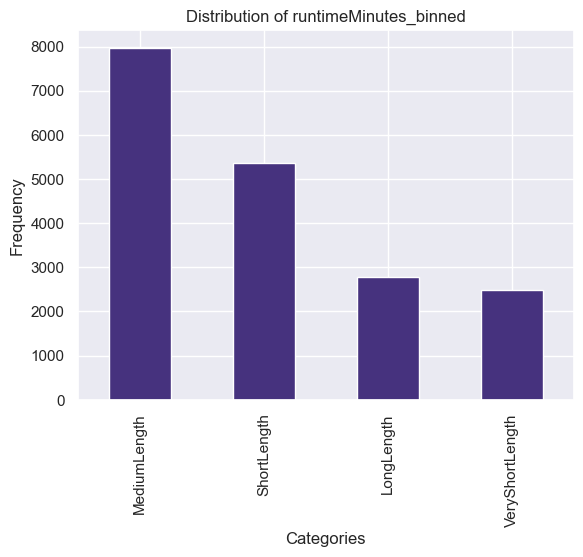

In [3]:
# Discretize `runtimeMinutes` into 4 bins considering min 0 and max 176
bins = [0, 15, 30, 90, 176]  # Defining the bin edges
labels = ['VeryShortLength', 'ShortLength', 'MediumLength', 'LongLength']  # Defining the bin labels
data['runtimeMinutes_binned'] = pd.cut(data['runtimeMinutes'], bins=bins, labels=labels, right=True)

# Display the results
print(data[['runtimeMinutes', 'runtimeMinutes_binned']].head())

# Visualize the distribution
import matplotlib.pyplot as plt
data['runtimeMinutes_binned'].value_counts().plot(kind='bar')
plt.title('Distribution of runtimeMinutes_binned')
plt.xlabel('Categories')
plt.ylabel('Frequency')
plt.show()



In [4]:
# Discretize `startYearDecade` into 4 bins: Pre-1960, 1960-1980, 1980-2000, Post-2000
bins = [-float('inf'), 1960, 1980, 2000, float('inf')]
labels = ['Pre-1960', '1960-1980', '1980-2000', 'Post-2000']

data['startYearDecade_binned'] = pd.cut(data['startYearDecade'], bins=bins, labels=labels)

# Display the results
print(data[['startYearDecade', 'startYearDecade_binned']].head())

# Check the value counts of the bins
print(data['startYearDecade_binned'].value_counts())


   startYearDecade startYearDecade_binned
0             1990              1980-2000
1             1990              1980-2000
2             2020              Post-2000
3             1990              1980-2000
4             1990              1980-2000
startYearDecade_binned
Post-2000    5772
1980-2000    5410
1960-1980    3811
Pre-1960     3591
Name: count, dtype: int64


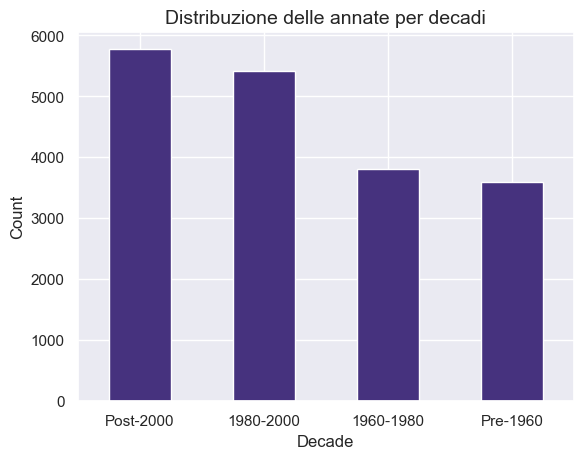

In [5]:
# Creare il grafico a barre
data['startYearDecade_binned'].value_counts().plot(kind='bar')

# Aggiungere etichette e titolo
plt.title('Distribuzione delle annate per decadi', fontsize=14)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)  # Mantenere le etichette sull'asse x orizzontali
plt.show()


   rating rating_binned
0       8     HighRated
1       6   MediumRated
2       6   MediumRated
3       9     HighRated
4       8     HighRated


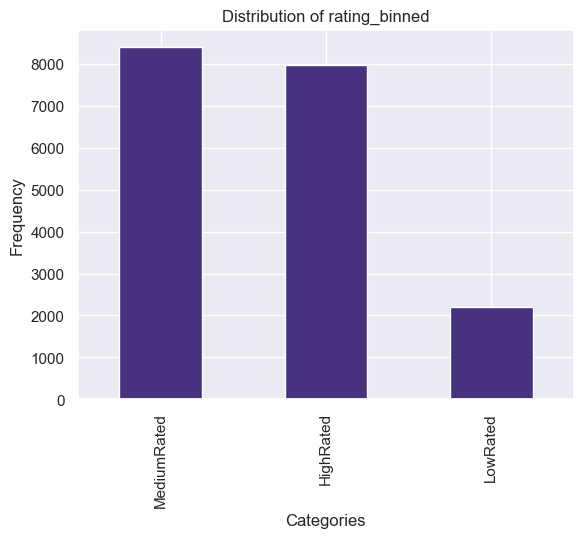

In [6]:
# Discretize `rating` into 3 bins considering min 0 and max 10
bins = [0, 5, 7, 10]  # Defining the bin edges
labels = ['LowRated', 'MediumRated', 'HighRated']  # Defining the bin labels
data['rating_binned'] = pd.cut(data['rating'], bins=bins, labels=labels, include_lowest=True)

# Display the results
print(data[['rating', 'rating_binned']].head())

# Visualize the distribution
import matplotlib.pyplot as plt
data['rating_binned'].value_counts().plot(kind='bar')
plt.title('Distribution of rating_binned')
plt.xlabel('Categories')
plt.ylabel('Frequency')
plt.show()



To remember the Label Encoding of titleType:  
tvSeries -> 0  
movie -> 1
tvEpisode -> 2  
tvMovie -> 3  
video -> 7  
short -> 8

In [7]:
# Map the titleType label encoded values to categories
title_type_mapping = {
    0: 'TvSeries',       # tvSeries
    1: 'Movie',    # movie
    2: 'TvEpisode',       # tvEpisode
    3: 'TvMovie',    # tvMovie
    7: 'Video',    # video
    8: 'Short'     # short
}

data['titleType_binned'] = data['titleType'].map(title_type_mapping)

# Display the results
print(data[['titleType', 'titleType_binned']].head())

# Check the value counts of the new bins
print(data['titleType_binned'].value_counts())


   titleType titleType_binned
0          2        TvEpisode
1          1            Movie
2          0         TvSeries
3          7            Video
4          2        TvEpisode
titleType_binned
Movie        6869
TvEpisode    5218
Short        2859
TvSeries     1640
TvMovie      1075
Video         923
Name: count, dtype: int64


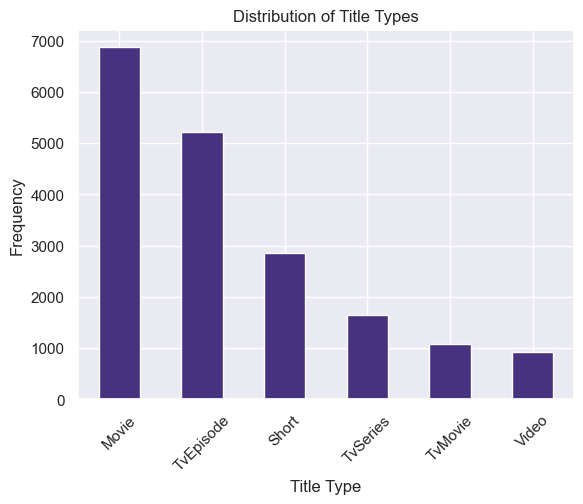

In [8]:
# Plot the distribution of titleType_binned
data['titleType_binned'].value_counts().plot(kind='bar')

# Customize the plot
plt.title('Distribution of Title Types')
plt.xlabel('Title Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.show()


In [9]:
# Minimum and maximum values of the numVotes category
min_votes = data['numVotes'].min()
max_votes = data['numVotes'].max()

print(f"Minimum numVotes: {min_votes}")
print(f"Maximum numVotes: {max_votes}")

Minimum numVotes: 5
Maximum numVotes: 14906


   numVotes numVotes_binned
0       779       HighVotes
1        38     MediumVotes
2        15        LowVotes
3        14        LowVotes
4        96     MediumVotes


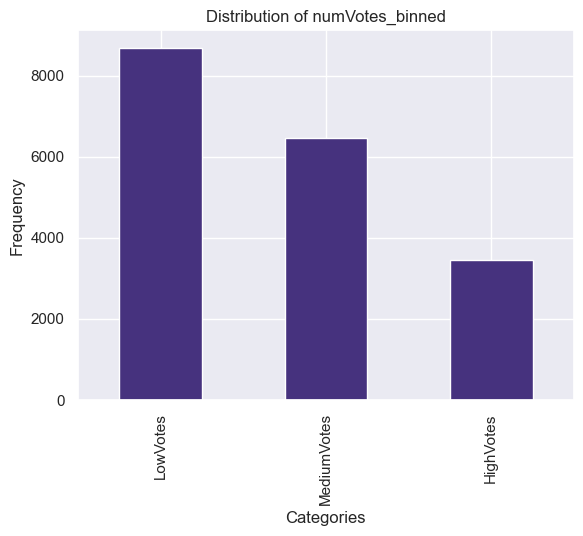

In [10]:
# Discretize `numVotes` into 4 bins
bins = [0, 30, 200, float('inf')]  # Adjust the bin ranges as needed
labels = ['LowVotes', 'MediumVotes', 'HighVotes']

data['numVotes_binned'] = pd.cut(data['numVotes'], bins=bins, labels=labels)

# Display the first few rows with the binned values
print(data[['numVotes', 'numVotes_binned']].head())

# Plot the distribution of the binned numVotes
import matplotlib.pyplot as plt
data['numVotes_binned'].value_counts().plot(kind='bar')
plt.title('Distribution of numVotes_binned')
plt.xlabel('Categories')
plt.ylabel('Frequency')
plt.show()


          genre_group
0  Action & Adventure
1      Comedy & Drama
2               Other
3               Other
4      Comedy & Drama


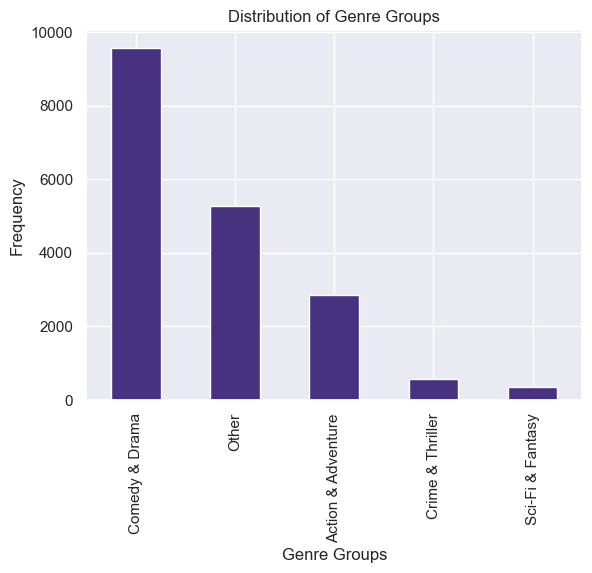

In [11]:
# Define categories by grouping genres
data['genre_group'] = data.apply(lambda row: 'Action & Adventure' if row['Action'] == 1 or row['Adventure'] == 1
                                else ('Comedy & Drama' if row['Comedy'] == 1 or row['Drama'] == 1
                                      else ('Sci-Fi & Fantasy' if row['Sci-Fi'] == 1 or row['Fantasy'] == 1
                                            else ('Crime & Thriller' if row['Crime'] == 1 or row['Thriller'] == 1
                                                  else 'Other'))), axis=1)

# Check the result
print(data[['genre_group']].head())

# Visualize the distribution of genre groups
data['genre_group'].value_counts().plot(kind='bar')
plt.title('Distribution of Genre Groups')
plt.xlabel('Genre Groups')
plt.ylabel('Frequency')
plt.show()


In [12]:
# Sum the genre columns to count the frequency of each genre
genre_columns = ['Action', 'Adult', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 
                 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show', 'History', 
                 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 
                 'Short', 'Sport', 'Talk-Show', 'Thriller', 'War', 'Western', 'unknown']

# Create a new column 'genres_combined' that concatenates the genres for each record
data['genres_combined'] = data[genre_columns].apply(lambda row: ','.join([genre for genre in genre_columns if row[genre] == 1]), axis=1)

# Preview the result
print(data[['genres_combined']].head())


              genres_combined
0  Action,Adventure,Animation
1                      Comedy
2                  Reality-TV
3           Documentary,Short
4               Drama,Romance


In [13]:
columns_of_interest = ['titleType_binned', 'runtimeMinutes_binned', 'startYearDecade_binned', 'rating_binned', 'numVotes_binned', 'genres_combined']

# First, split the genres by commas and create a list of transactions
data['genres_combined'] = data['genres_combined'].str.split(',')  # Split genres by comma

# Now, create the transactions, converting the genres list to individual items in the transaction
transactions = []

for index, row in data[columns_of_interest].iterrows():
    # Start by adding the fixed columns
    transaction = [str(row[col]) for col in columns_of_interest[:-1]]  # All columns except genres
    # Add genres as individual items (flatten them)
    for genre in row['genres_combined']:
        transaction.append(genre.strip())  # Remove any leading/trailing spaces from genres
    transactions.append(transaction)

# Print the first few transactions to verify
print(len(transactions))
print(transactions[:5])  # Display first 5 transactions

18584
[['TvEpisode', 'ShortLength', '1980-2000', 'HighRated', 'HighVotes', 'Action', 'Adventure', 'Animation'], ['Movie', 'MediumLength', '1980-2000', 'MediumRated', 'MediumVotes', 'Comedy'], ['TvSeries', 'ShortLength', 'Post-2000', 'MediumRated', 'LowVotes', 'Reality-TV'], ['Video', 'MediumLength', '1980-2000', 'HighRated', 'LowVotes', 'Documentary', 'Short'], ['TvEpisode', 'MediumLength', '1980-2000', 'HighRated', 'MediumVotes', 'Drama', 'Romance']]


In [14]:
# Let's utilize TransactionEncoder
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_apriori = pd.DataFrame(te_array, columns=te.columns_)

# Visualizza le prime righe per assicurarti che la trasformazione sia corretta
print(df_apriori.head())

   1960-1980  1980-2000  Action  Adult  Adventure  Animation  Biography  \
0      False       True    True  False       True       True      False   
1      False       True   False  False      False      False      False   
2      False      False   False  False      False      False      False   
3      False       True   False  False      False      False      False   
4      False       True   False  False      False      False      False   

   Comedy  Crime  Documentary  ...  Thriller  TvEpisode  TvMovie  TvSeries  \
0   False  False        False  ...     False       True    False     False   
1    True  False        False  ...     False      False    False     False   
2   False  False        False  ...     False      False    False      True   
3   False  False         True  ...     False      False    False     False   
4   False  False        False  ...     False       True    False     False   

   VeryShortLength  Video    War  Western    nan  unknown  
0            False  

Support 0.02 - Frequent and Closed Itemsets are identical.
Support 0.04 - Frequent and Closed Itemsets are identical.
Support 0.05 - Frequent and Closed Itemsets are identical.
Support 0.06 - Frequent and Closed Itemsets are identical.
Support 0.07 - Frequent and Closed Itemsets are identical.
Support 0.09 - Frequent and Closed Itemsets are identical.
Support 0.10 - Frequent and Closed Itemsets are identical.
Support 0.11 - Frequent and Closed Itemsets are identical.
Support 0.12 - Frequent and Closed Itemsets are identical.
Support 0.14 - Frequent and Closed Itemsets are identical.
Support 0.15 - Frequent and Closed Itemsets are identical.
Support 0.16 - Frequent and Closed Itemsets are identical.
Support 0.17 - Frequent and Closed Itemsets are identical.
Support 0.19 - Frequent and Closed Itemsets are identical.
Support 0.20 - Frequent and Closed Itemsets are identical.
Support 0.21 - Frequent and Closed Itemsets are identical.
Support 0.22 - Frequent and Closed Itemsets are identica

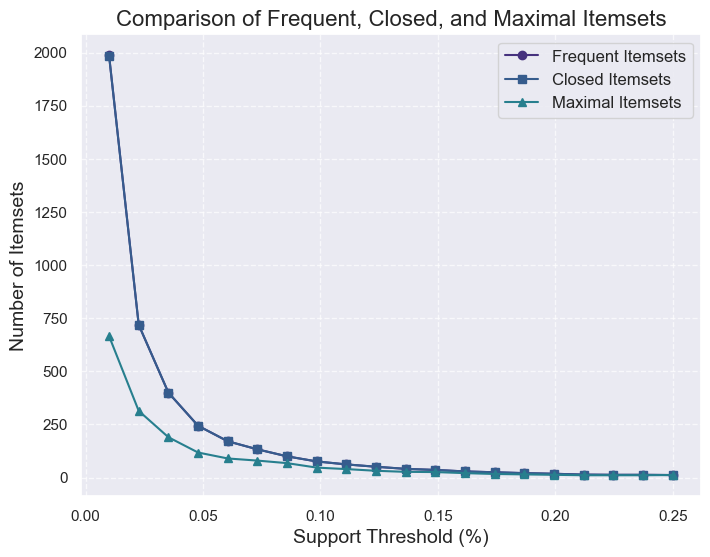

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori
import pandas as pd

# Range di supporti da testare
min_support = 0.01  # Supporto minimo 1%
max_support = 0.25  # Supporto massimo 25%
support_values = np.linspace(min_support, max_support, 20)

# Liste per memorizzare i conteggi degli itemsets
frequent_itemsets_counts = []
closed_itemsets_counts = []
maximal_itemsets_counts = []

for support in support_values:
    # Itemsets frequenti
    frequent_itemsets = apriori(df_apriori, min_support=support, use_colnames=True)
    
    # Closed itemsets: itemsets che non sono subset di altri con lo stesso supporto
    closed_itemsets = frequent_itemsets[frequent_itemsets.apply(
        lambda row: not any(
            set(row['itemsets']).issubset(set(other)) and row['support'] == frequent_itemsets[frequent_itemsets['itemsets'] == other]['support'].values[0]
            for other in frequent_itemsets['itemsets'] if row['itemsets'] != other
        ), axis=1
    )]
    
    # Maximal itemsets: itemsets che non sono un subset di altri itemsets
    maximal_itemsets = frequent_itemsets[frequent_itemsets.apply(
        lambda row: not any(
            set(row['itemsets']).issubset(set(other)) and row['itemsets'] != other
            for other in frequent_itemsets['itemsets']
        ), axis=1
    )]
    
    # Memorizza i conteggi degli itemsets
    frequent_itemsets_counts.append(len(frequent_itemsets))
    closed_itemsets_counts.append(len(closed_itemsets))
    maximal_itemsets_counts.append(len(maximal_itemsets))

    # Verifica se i frequent itemsets e i closed itemsets sono uguali
    if len(frequent_itemsets) == len(closed_itemsets):
        print(f"Support {support:.2f} - Frequent and Closed Itemsets are identical.")

# Crea il grafico
plt.figure(figsize=(8, 6))
plt.plot(support_values, frequent_itemsets_counts, marker='o', label='Frequent Itemsets')
plt.plot(support_values, closed_itemsets_counts, marker='s', label='Closed Itemsets')
plt.plot(support_values, maximal_itemsets_counts, marker='^', label='Maximal Itemsets')
plt.title("Comparison of Frequent, Closed, and Maximal Itemsets", fontsize=16)
plt.xlabel("Support Threshold (%)", fontsize=14)
plt.ylabel("Number of Itemsets", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.show()


Support 0.02 - Frequent and Closed Itemsets are identical.
Support 0.04 - Frequent and Closed Itemsets are identical.
Support 0.05 - Frequent and Closed Itemsets are identical.
Support 0.06 - Frequent and Closed Itemsets are identical.
Support 0.07 - Frequent and Closed Itemsets are identical.
Support 0.09 - Frequent and Closed Itemsets are identical.
Support 0.10 - Frequent and Closed Itemsets are identical.
Support 0.11 - Frequent and Closed Itemsets are identical.
Support 0.12 - Frequent and Closed Itemsets are identical.
Support 0.14 - Frequent and Closed Itemsets are identical.
Support 0.15 - Frequent and Closed Itemsets are identical.
Support 0.16 - Frequent and Closed Itemsets are identical.
Support 0.17 - Frequent and Closed Itemsets are identical.
Support 0.19 - Frequent and Closed Itemsets are identical.
Support 0.20 - Frequent and Closed Itemsets are identical.
Support 0.21 - Frequent and Closed Itemsets are identical.
Support 0.22 - Frequent and Closed Itemsets are identica

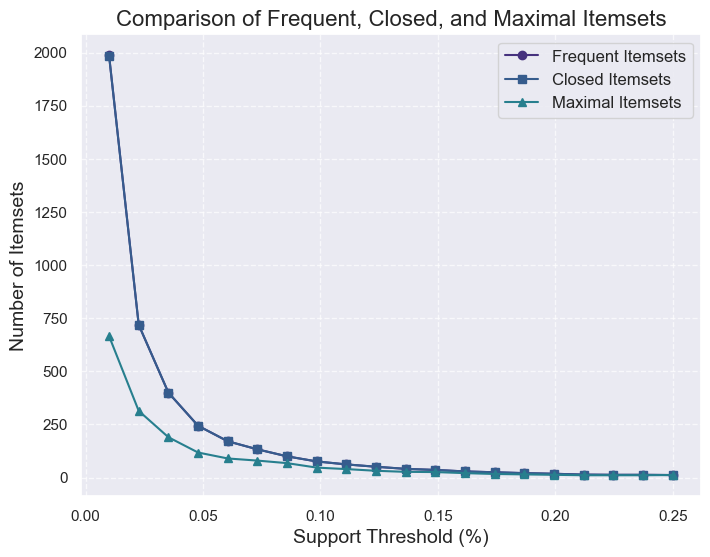

In [16]:
# Range di supporti da testare
min_support = 0.01  # Supporto minimo 1%
max_support = 0.25  # Supporto massimo 25%
support_values = np.linspace(min_support, max_support, 20)

# Liste per memorizzare i conteggi degli itemsets
frequent_itemsets_counts = []
closed_itemsets_counts = []
maximal_itemsets_counts = []

for support in support_values:
    # Itemsets frequenti usando FP-growth
    frequent_itemsets = fpgrowth(df_apriori, min_support=support, use_colnames=True)
    
    # Closed itemsets: itemsets che non sono subset di altri con lo stesso supporto
    closed_itemsets = frequent_itemsets[frequent_itemsets.apply(
        lambda row: not any(
            set(row['itemsets']).issubset(set(other)) and row['support'] == frequent_itemsets[frequent_itemsets['itemsets'] == other]['support'].values[0]
            for other in frequent_itemsets['itemsets'] if row['itemsets'] != other
        ), axis=1
    )]
    
    # Maximal itemsets: itemsets che non sono un subset di altri itemsets
    maximal_itemsets = frequent_itemsets[frequent_itemsets.apply(
        lambda row: not any(
            set(row['itemsets']).issubset(set(other)) and row['itemsets'] != other
            for other in frequent_itemsets['itemsets']
        ), axis=1
    )]
    
    # Memorizza i conteggi degli itemsets
    frequent_itemsets_counts.append(len(frequent_itemsets))
    closed_itemsets_counts.append(len(closed_itemsets))
    maximal_itemsets_counts.append(len(maximal_itemsets))

    # Verifica se i frequent itemsets e i closed itemsets sono uguali
    if len(frequent_itemsets) == len(closed_itemsets):
        print(f"Support {support:.2f} - Frequent and Closed Itemsets are identical.")

# Crea il grafico
plt.figure(figsize=(8, 6))
plt.plot(support_values, frequent_itemsets_counts, marker='o', label='Frequent Itemsets')
plt.plot(support_values, closed_itemsets_counts, marker='s', label='Closed Itemsets')
plt.plot(support_values, maximal_itemsets_counts, marker='^', label='Maximal Itemsets')
plt.title("Comparison of Frequent, Closed, and Maximal Itemsets", fontsize=16)
plt.xlabel("Support Threshold (%)", fontsize=14)
plt.ylabel("Number of Itemsets", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.show()


### Frequent Itemsets

In [17]:
# Dato che un supporto del 10% (0.1) bilancia meglio semplicità, rilevanza e riduzione della complessità, è l'opzione 
# più efficace per un'analisi strutturata.

min_support = 0.10  # 10% supporto minimo
min_confidence = 0.6  # 60% confidenza minima

# Apriori
frequent_itemsets_apriori = apriori(df_apriori, min_support=min_support, use_colnames=True)
# Filtra gli itemset con almeno 2 item (lunghezza >= 2)
#frequent_itemsets_apriori = frequent_itemsets_apriori[frequent_itemsets_apriori['itemsets'].apply(lambda x: len(x) >= 2)]
#frequent_itemsets_apriori.reset_index(drop=True, inplace=True)

print(frequent_itemsets_apriori.info())
print(frequent_itemsets_apriori.head(51))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   support   73 non-null     float64
 1   itemsets  73 non-null     object 
dtypes: float64(1), object(1)
memory usage: 1.3+ KB
None
     support                   itemsets
0   0.205069                (1960-1980)
1   0.291111                (1980-2000)
2   0.106220                   (Action)
3   0.300151                   (Comedy)
4   0.116175              (Documentary)
5   0.356382                    (Drama)
6   0.429294                (HighRated)
7   0.185213                (HighVotes)
8   0.149322               (LongLength)
9   0.118812                 (LowRated)
10  0.467391                 (LowVotes)
11  0.428971             (MediumLength)
12  0.451894              (MediumRated)
13  0.347396              (MediumVotes)
14  0.369619                    (Movie)
15  0.310590                (Post-2000)
16  0

In [18]:
# FP-Growth
frequent_itemsets_fpgrowth = fpgrowth(df_apriori, min_support=min_support, use_colnames=True)

# Filtra gli itemset con almeno 2 item (lunghezza >= 2)
#frequent_itemsets_fpgrowth = frequent_itemsets_fpgrowth[frequent_itemsets_fpgrowth['itemsets'].apply(lambda x: len(x) >= 2)]
#frequent_itemsets_fpgrowth.reset_index(drop=True, inplace=True)

# Visualizza i risultati
print(frequent_itemsets_fpgrowth.info())
print(frequent_itemsets_fpgrowth.head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   support   73 non-null     float64
 1   itemsets  73 non-null     object 
dtypes: float64(1), object(1)
memory usage: 1.3+ KB
None
     support        itemsets
0   0.429294     (HighRated)
1   0.291111     (1980-2000)
2   0.288420   (ShortLength)
3   0.280779     (TvEpisode)
4   0.185213     (HighVotes)
5   0.106220        (Action)
6   0.451894   (MediumRated)
7   0.428971  (MediumLength)
8   0.369619         (Movie)
9   0.347396   (MediumVotes)
10  0.300151        (Comedy)
11  0.467391      (LowVotes)
12  0.310590     (Post-2000)
13  0.168209         (Short)
14  0.116175   (Documentary)


### Maximal Itemsets

In [19]:
# Find maximal itemsets (those that are not subsets of any other itemsets)
maximal_itemsets_apriori = frequent_itemsets_apriori[frequent_itemsets_apriori['itemsets'].apply(lambda x: not any(x < y for y in frequent_itemsets_apriori['itemsets']))]

# Display the results
print(maximal_itemsets_apriori.info())
print(maximal_itemsets_apriori.head(15))


<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 0 to 72
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   support   44 non-null     float64
 1   itemsets  44 non-null     object 
dtypes: float64(1), object(1)
memory usage: 1.0+ KB
None
     support                   itemsets
0   0.205069                (1960-1980)
2   0.106220                   (Action)
4   0.116175              (Documentary)
9   0.118812                 (LowRated)
21  0.137645     (HighRated, 1980-2000)
22  0.140605      (LowVotes, 1980-2000)
23  0.120426  (MediumLength, 1980-2000)
24  0.119727   (MediumRated, 1980-2000)
25  0.133932        (HighRated, Comedy)
26  0.122794         (LowVotes, Comedy)
27  0.132533      (MediumRated, Comedy)
28  0.110633      (MediumVotes, Comedy)
31  0.154703         (HighRated, Drama)
32  0.135816          (LowVotes, Drama)
33  0.177787      (MediumLength, Drama)


In [20]:
# Find maximal itemsets (those that are not subsets of any other itemsets)
maximal_itemsets_fpgrowth = frequent_itemsets_fpgrowth[frequent_itemsets_fpgrowth['itemsets'].apply(lambda x: not any(x < y for y in frequent_itemsets_fpgrowth['itemsets']))]

# Display the results
print(maximal_itemsets_fpgrowth.info())
print(maximal_itemsets_fpgrowth.head(15))

<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 5 to 72
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   support   44 non-null     float64
 1   itemsets  44 non-null     object 
dtypes: float64(1), object(1)
memory usage: 1.0+ KB
None
     support                             itemsets
5   0.106220                             (Action)
14  0.116175                        (Documentary)
18  0.118812                           (LowRated)
20  0.205069                          (1960-1980)
21  0.202970                (LowVotes, HighRated)
22  0.137645               (HighRated, 1980-2000)
23  0.120426            (MediumLength, 1980-2000)
24  0.119727             (MediumRated, 1980-2000)
25  0.140605                (LowVotes, 1980-2000)
27  0.142434              (ShortLength, LowVotes)
29  0.102561           (ShortLength, MediumVotes)
32  0.110041             (TvEpisode, MediumVotes)
33  0.103691                   (TvEpisod

### Association Rules

In [21]:
#Apriori
rules_apriori = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=min_confidence)
rules_apriori.info()
rules_apriori.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   antecedents         19 non-null     object 
 1   consequents         19 non-null     object 
 2   antecedent support  19 non-null     float64
 3   consequent support  19 non-null     float64
 4   support             19 non-null     float64
 5   confidence          19 non-null     float64
 6   lift                19 non-null     float64
 7   leverage            19 non-null     float64
 8   conviction          19 non-null     float64
 9   zhangs_metric       19 non-null     float64
dtypes: float64(8), object(2)
memory usage: 1.6+ KB


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(ShortLength),(HighRated),0.288420,0.429294,0.179563,0.622575,1.450229,0.055746,1.512103,0.436288
1,(TvEpisode),(HighRated),0.280779,0.429294,0.198504,0.706976,1.646834,0.077967,1.947641,0.546111
2,(LongLength),(Movie),0.149322,0.369619,0.129090,0.864505,2.338907,0.073897,4.652413,0.672934
3,(Short),(LowVotes),0.168209,0.467391,0.118866,0.706654,1.511911,0.040246,1.815632,0.407056
4,(Movie),(MediumLength),0.369619,0.428971,0.240529,0.650750,1.517001,0.081974,1.635013,0.540633
5,(Short),(VeryShortLength),0.168209,0.133233,0.121933,0.724888,5.440759,0.099522,3.150598,0.981259
6,(VeryShortLength),(Short),0.133233,0.168209,0.121933,0.915186,5.440759,0.099522,9.807209,0.941663
7,(ShortLength),(TvEpisode),0.288420,0.280779,0.181231,0.628358,2.237909,0.100249,1.935253,0.777361
8,(TvEpisode),(ShortLength),0.280779,0.288420,0.181231,0.645458,2.237909,0.100249,2.007040,0.769102
9,"(ShortLength, Comedy)",(TvEpisode),0.131403,0.280779,0.100194,0.762490,2.715621,0.063298,3.028168,0.727334


In [22]:
#FP-Growth
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="confidence", min_threshold=min_confidence)
rules_fpgrowth.info()
rules_fpgrowth.head(18)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   antecedents         19 non-null     object 
 1   consequents         19 non-null     object 
 2   antecedent support  19 non-null     float64
 3   consequent support  19 non-null     float64
 4   support             19 non-null     float64
 5   confidence          19 non-null     float64
 6   lift                19 non-null     float64
 7   leverage            19 non-null     float64
 8   conviction          19 non-null     float64
 9   zhangs_metric       19 non-null     float64
dtypes: float64(8), object(2)
memory usage: 1.6+ KB


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(ShortLength),(HighRated),0.288420,0.429294,0.179563,0.622575,1.450229,0.055746,1.512103,0.436288
1,(TvEpisode),(HighRated),0.280779,0.429294,0.198504,0.706976,1.646834,0.077967,1.947641,0.546111
2,(ShortLength),(TvEpisode),0.288420,0.280779,0.181231,0.628358,2.237909,0.100249,1.935253,0.777361
3,(TvEpisode),(ShortLength),0.280779,0.288420,0.181231,0.645458,2.237909,0.100249,2.007040,0.769102
4,"(ShortLength, TvEpisode)",(HighRated),0.181231,0.429294,0.126345,0.697150,1.623944,0.048544,1.884449,0.469260
5,"(ShortLength, HighRated)",(TvEpisode),0.179563,0.280779,0.126345,0.703626,2.505977,0.075928,2.426734,0.732480
6,"(HighRated, TvEpisode)",(ShortLength),0.198504,0.288420,0.126345,0.636487,2.206804,0.069093,1.957508,0.682294
7,"(ShortLength, Comedy)",(TvEpisode),0.131403,0.280779,0.100194,0.762490,2.715621,0.063298,3.028168,0.727334
8,"(TvEpisode, Comedy)",(ShortLength),0.122794,0.288420,0.100194,0.815951,2.829036,0.064778,3.866251,0.737025
9,(Movie),(MediumLength),0.369619,0.428971,0.240529,0.650750,1.517001,0.081974,1.635013,0.540633


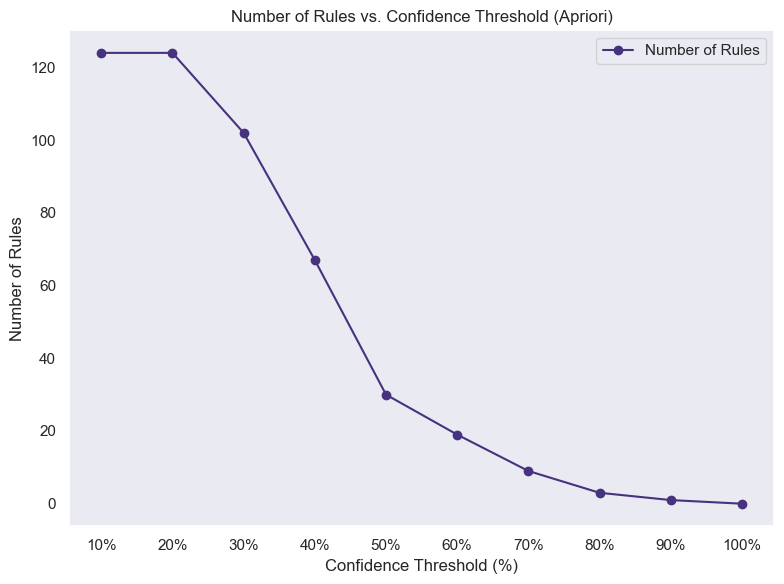

In [23]:
# Itera su diverse confidence e raccogli i dati
confidence_thresholds = np.linspace(0.1, 1.0, 10)
num_rules = []

for conf in confidence_thresholds:
    rules = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=conf)
    num_rules.append(len(rules))

# Grafico dei risultati
plt.figure(figsize=(8, 6))
plt.plot(confidence_thresholds, num_rules, marker='o', label="Number of Rules")
plt.title("Number of Rules vs. Confidence Threshold (Apriori)")
plt.xlabel("Confidence Threshold (%)")
plt.ylabel("Number of Rules")
plt.xticks(confidence_thresholds, labels=[f"{int(c*100)}%" for c in confidence_thresholds])
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


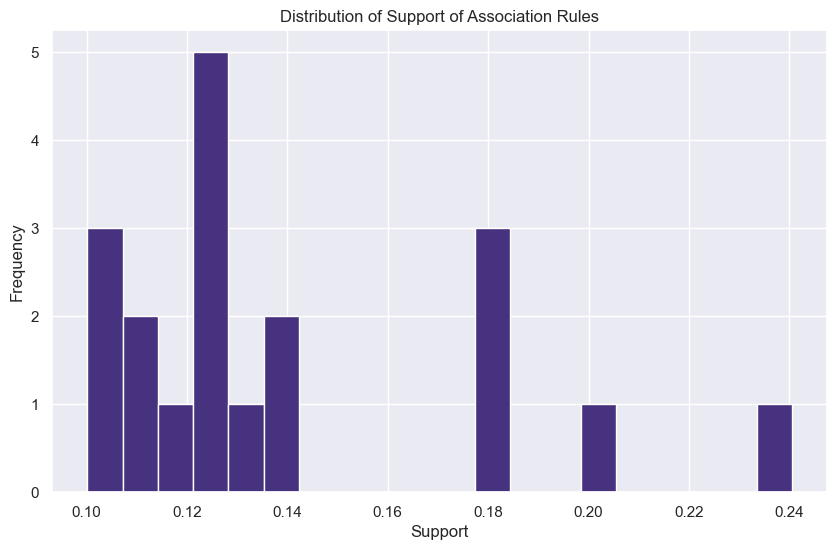

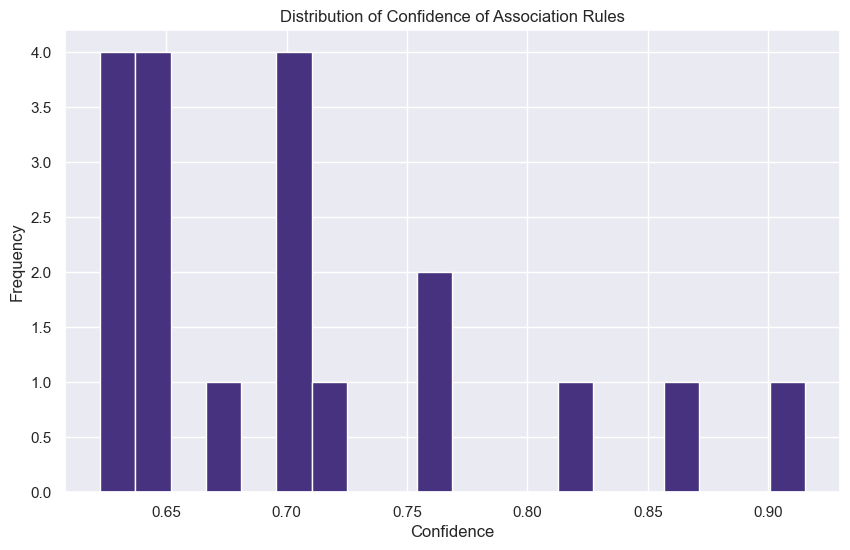

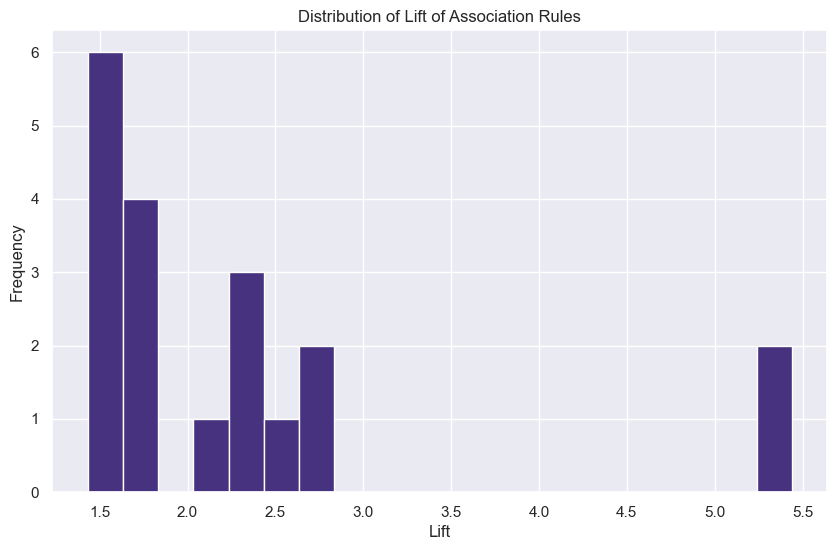

In [24]:
# Visualize rules support
plt.figure(figsize=(10, 6))
plt.hist(rules_apriori['support'], bins=20)
plt.title('Distribution of Support of Association Rules')
plt.xlabel('Support')
plt.ylabel('Frequency')
plt.show()

# Visualize confidence support
plt.figure(figsize=(10, 6))
plt.hist(rules_apriori['confidence'], bins=20)
plt.title('Distribution of Confidence of Association Rules')
plt.xlabel('Confidence')
plt.ylabel('Frequency')
plt.show()

# Visualize lift support
plt.figure(figsize=(10, 6))
plt.hist(rules_apriori['lift'], bins=20)
plt.title('Distribution of Lift of Association Rules')
plt.xlabel('Lift')
plt.ylabel('Frequency')
plt.show()


In [25]:
rules_apriori.sort_values(by="lift", axis=0, ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
6,(VeryShortLength),(Short),0.133233,0.168209,0.121933,0.915186,5.440759,0.099522,9.807209,0.941663
5,(Short),(VeryShortLength),0.168209,0.133233,0.121933,0.724888,5.440759,0.099522,3.150598,0.981259
10,"(TvEpisode, Comedy)",(ShortLength),0.122794,0.288420,0.100194,0.815951,2.829036,0.064778,3.866251,0.737025
9,"(ShortLength, Comedy)",(TvEpisode),0.131403,0.280779,0.100194,0.762490,2.715621,0.063298,3.028168,0.727334
14,"(ShortLength, HighRated)",(TvEpisode),0.179563,0.280779,0.126345,0.703626,2.505977,0.075928,2.426734,0.732480
2,(LongLength),(Movie),0.149322,0.369619,0.129090,0.864505,2.338907,0.073897,4.652413,0.672934
8,(TvEpisode),(ShortLength),0.280779,0.288420,0.181231,0.645458,2.237909,0.100249,2.007040,0.769102
7,(ShortLength),(TvEpisode),0.288420,0.280779,0.181231,0.628358,2.237909,0.100249,1.935253,0.777361
15,"(HighRated, TvEpisode)",(ShortLength),0.198504,0.288420,0.126345,0.636487,2.206804,0.069093,1.957508,0.682294
17,"(MediumRated, MediumLength)",(Movie),0.202002,0.369619,0.136461,0.675546,1.827682,0.061798,1.942898,0.567494


### Target Prediction: HighRated

In [26]:
# Filtro le regole con "HighRated" nei consequents
rules_highrated = rules_apriori[rules_apriori['consequents'] == frozenset({'HighRated'})]

# Ordina le regole per lift in ordine decrescente
rules_highrated_sorted = rules_highrated.sort_values(by='lift', ascending=False)

print(rules_highrated_sorted)

                 antecedents  consequents  antecedent support  \
1                (TvEpisode)  (HighRated)            0.280779   
13  (ShortLength, TvEpisode)  (HighRated)            0.181231   
0              (ShortLength)  (HighRated)            0.288420   

    consequent support   support  confidence      lift  leverage  conviction  \
1             0.429294  0.198504    0.706976  1.646834  0.077967    1.947641   
13            0.429294  0.126345    0.697150  1.623944  0.048544    1.884449   
0             0.429294  0.179563    0.622575  1.450229  0.055746    1.512103   

    zhangs_metric  
1        0.546111  
13       0.469260  
0        0.436288  


In [27]:
# Filter the rule where the consequent contains "HighRated"
rule_for_highrated = [r for r in rules_apriori.iterrows() if 'HighRated' in r[1]['consequents']]

# Extract rule details (antecedents and consequents)
if len(rule_for_highrated) > 0:
    selected_rule = rule_for_highrated[0][1]  # Take the first matching rule
    to_predict = ", ".join(selected_rule['consequents'])  # Convert frozenset to string
    how = ", ".join(selected_rule['antecedents'])  # Convert frozenset to string

    print("To predict:", to_predict)
    print("How?", how)
else:
    print("No rules found with 'HighRated' in the consequents.")


To predict: HighRated
How? ShortLength
